In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv("C:/Users/vidhy/OneDrive/Pictures/Documents/test_data.csv")
df

,Unnamed: 0,PassengerId,Survived,Sex,Age,Fare,Pclass_1,Pclass_2,Pclass_3,Family_size,Title_1,Title_2,Title_3,Title_4,Emb_1,Emb_2,Emb_3
0,791,792,0,1,0.2000,0.050749,0,1,0,0.0,1,0,0,0,0,0,1
1,792,793,0,0,0.3500,0.135753,0,0,1,1.0,0,0,0,1,0,0,1
2,793,794,0,1,0.3500,0.059914,1,0,0,0.0,1,0,0,0,1,0,0
3,794,795,0,1,0.3125,0.015412,0,0,1,0.0,1,0,0,0,0,0,1
4,795,796,0,1,0.4875,0.025374,0,1,0,0.0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,886,887,0,1,0.3375,0.025374,0,1,0,0.0,1,0,0,0,0,0,1
96,887,888,1,0,0.2375,0.058556,1,0,0,0.0,0,0,0,1,0,0,1
97,888,889,0,0,0.3500,0.045771,0,0,1,0.3,0,0,0,1,0,0,1
98,889,890,1,1,0.3250,0.058556,1,0,0,0.0,1,0,0,0,1,0,0


In [31]:
df.drop(['Unnamed: 0','PassengerId'], axis=1,inplace=True)

In [32]:
x=df

In [33]:
from sklearn.cluster import KMeans
wcss=[]
for i in range(1,31):
    data=KMeans(n_clusters=i,init='k-means++',random_state=42)
    data.fit(x)
    wcss.append(data.inertia_)
wcss

[188.913176785823,
 154.0847444255213,
 132.14295190624136,
 117.35153780779393,
 97.90923149245404,
 81.2391443528304,
 76.00159621757061,
 63.12566503470907,
 57.67262038565214,
 54.096383368883956,
 44.74298101599007,
 41.64121002168146,
 37.34527606821462,
 34.03641797593676,
 29.41204697612002,
 26.417319033196076,
 23.163755362993243,
 21.11419106648469,
 20.256960312022493,
 18.991036909776113,
 16.087304060367515,
 14.900668769545122,
 13.034000937921407,
 12.000878811566835,
 10.307190643282919,
 9.306553643237459,
 8.218125697265094,
 7.551041957553464,
 7.028106909290212,
 6.313011430133995]

Text(0.5, 1.0, 'Elbow points')

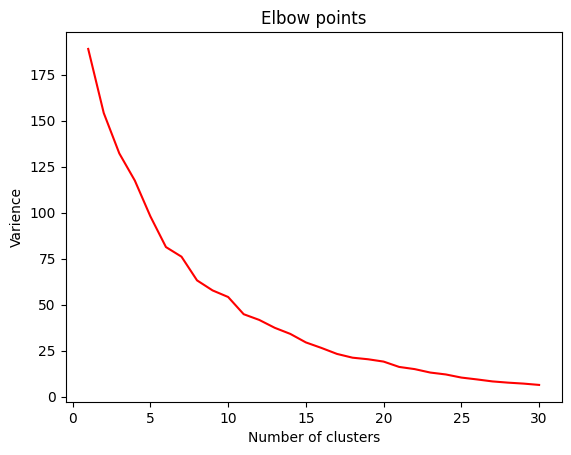

In [34]:
plt.plot(range(1,31),wcss,color='r')
plt.xlabel('Number of clusters')
plt.ylabel('Varience')
plt.title('Elbow points')

In [35]:
data1=KMeans(n_clusters=20,init='k-means++',random_state=42)
data1.fit(x)
y_pred=data1.predict(x)

In [36]:
y_pred

array([ 5, 19, 11,  1,  5,  3,  8, 10,  8,  5, 14, 15,  9,  8,  1,  6,  4,
        5,  3,  1,  1,  5, 19,  1,  6,  4, 16,  1,  7,  3,  8,  6,  8,  7,
       18,  1,  9,  0,  2, 12, 15, 10,  1,  1, 17,  1,  1,  8, 11,  1,  5,
       17, 10,  1,  1,  1, 10,  5,  2,  7,  1,  4, 13, 14,  8,  3,  6, 12,
       10,  1,  5,  3, 19,  5, 14, 16,  6,  1,  7,  1,  3,  6,  1, 16, 12,
        1,  1,  1,  2, 14,  1,  4,  5,  1, 18,  5, 13,  4, 11, 18],
      dtype=int32)

In [37]:
x['cluster']=y_pred
x

,Survived,Sex,Age,Fare,Pclass_1,Pclass_2,Pclass_3,Family_size,Title_1,Title_2,Title_3,Title_4,Emb_1,Emb_2,Emb_3,cluster
0,0,1,0.2000,0.050749,0,1,0,0.0,1,0,0,0,0,0,1,5
1,0,0,0.3500,0.135753,0,0,1,1.0,0,0,0,1,0,0,1,19
2,0,1,0.3500,0.059914,1,0,0,0.0,1,0,0,0,1,0,0,11
3,0,1,0.3125,0.015412,0,0,1,0.0,1,0,0,0,0,0,1,1
4,0,1,0.4875,0.025374,0,1,0,0.0,1,0,0,0,0,0,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0,1,0.3375,0.025374,0,1,0,0.0,1,0,0,0,0,0,1,5
96,1,0,0.2375,0.058556,1,0,0,0.0,0,0,0,1,0,0,1,13
97,0,0,0.3500,0.045771,0,0,1,0.3,0,0,0,1,0,0,1,4
98,1,1,0.3250,0.058556,1,0,0,0.0,1,0,0,0,1,0,0,11


In [38]:
data1=x.iloc[:,:-1].values
data2=x.iloc[:,-1].values
data1

array([[0.   , 1.   , 0.2  , ..., 0.   , 0.   , 1.   ],
       [0.   , 0.   , 0.35 , ..., 0.   , 0.   , 1.   ],
       [0.   , 1.   , 0.35 , ..., 1.   , 0.   , 0.   ],
       ...,
       [0.   , 0.   , 0.35 , ..., 0.   , 0.   , 1.   ],
       [1.   , 1.   , 0.325, ..., 1.   , 0.   , 0.   ],
       [0.   , 1.   , 0.4  , ..., 0.   , 1.   , 0.   ]], shape=(100, 15))

In [39]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(data1,data2,test_size=0.30,random_state=42)
x_train

array([[1.    , 1.    , 0.1375, ..., 0.    , 0.    , 1.    ],
       [1.    , 1.    , 0.4   , ..., 0.    , 0.    , 1.    ],
       [0.    , 1.    , 0.25  , ..., 0.    , 0.    , 1.    ],
       ...,
       [0.    , 1.    , 0.3875, ..., 0.    , 0.    , 1.    ],
       [0.    , 1.    , 0.35  , ..., 0.    , 0.    , 1.    ],
       [1.    , 0.    , 0.375 , ..., 1.    , 0.    , 0.    ]],
      shape=(70, 15))

In [41]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
scaler.fit(x_train)
x_train=scaler.transform(x_train)
x_test=scaler.transform(x_test)


In [42]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=20)
knn.fit(x_train,y_train)
y_pred=knn.predict(x_test)
y_pred

array([ 5,  1,  1,  1,  3,  8,  1,  8,  5,  1,  8,  1,  1,  1,  1,  1,  1,
        1, 10,  1,  1,  3,  5,  1,  1,  1,  5,  3,  1,  1], dtype=int32)

In [43]:
from sklearn.metrics import accuracy_score
score=accuracy_score(y_test,y_pred)
score


0.23333333333333334